# 扩展回归：SVM（SVR）、KNN、LightGBM

在 sklearn 糖尿病数据集上使用 **SVR**、**KNeighborsRegressor**、**LGBMRegressor**；评估 **MSE**、**R²**；绘制预测值 vs 真实值。


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

from lightgbm import LGBMRegressor

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


## 1. 数据加载与探索性分析


数据集形状： (442, 11)
缺失值： 0


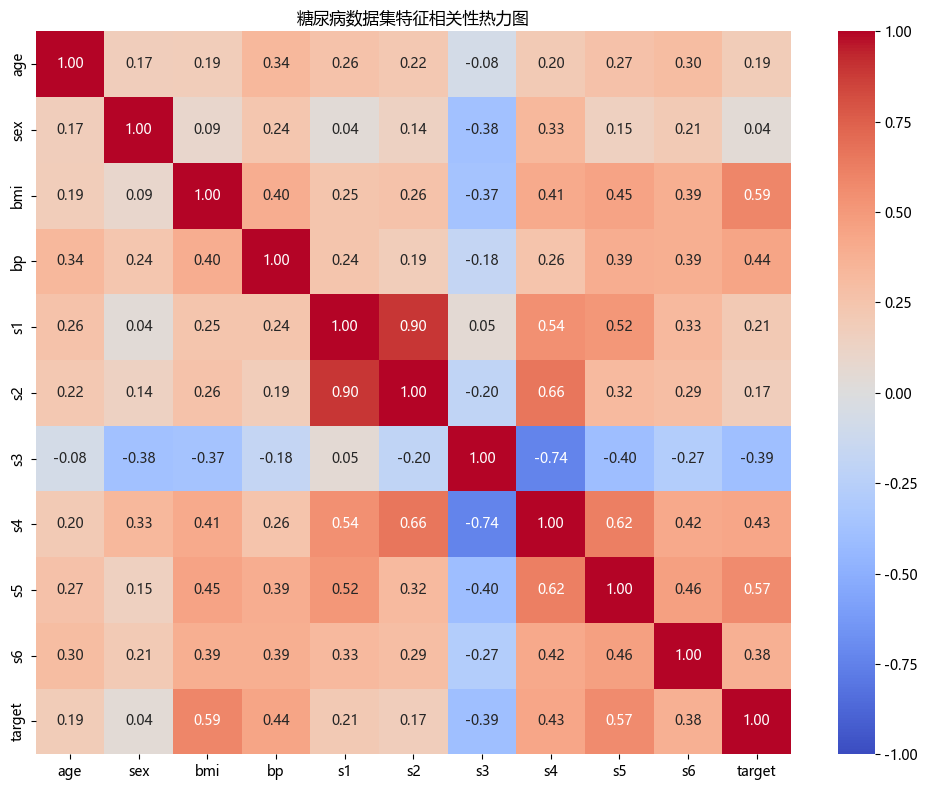

In [2]:
diabetes = load_diabetes()
diabetes_df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
diabetes_df["target"] = diabetes.target

print("数据集形状：", diabetes_df.shape)
print("缺失值：", diabetes_df.isnull().sum().sum())

X = diabetes_df.drop("target", axis=1)
y = diabetes_df["target"]

correlation_matrix = diabetes_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("糖尿病数据集特征相关性热力图")
plt.tight_layout()
plt.show()


## 2. 预处理：标准化与划分训练/测试集


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("标准化前特征均值（第1列）：", float(X.iloc[:, 0].mean()))
print("标准化后特征均值（第1列）：", round(float(X_scaled[:, 0].mean()), 2))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)
print("训练集样本数：", X_train.shape[0])
print("测试集样本数：", X_test.shape[0])


标准化前特征均值（第1列）： -2.511816797794472e-19
标准化后特征均值（第1列）： 0.0
训练集样本数： 309
测试集样本数： 133


## 3. 模型训练（SVR / KNN / LightGBM）


In [4]:
# SVR：RBF 核；C/epsilon 可后续调参
svr = SVR(kernel="rbf", C=10.0, epsilon=0.1)
svr.fit(X_train, y_train)
print("SVR 训练完成")

# KNN 回归：邻居数 k 可调整
knn_reg = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn_reg.fit(X_train, y_train)
print("KNN 回归训练完成")

# LightGBM 回归（sklearn 接口）
lgbm_reg = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    verbose=-1,
)
lgbm_reg.fit(X_train, y_train)
print("LightGBM 回归训练完成")


SVR 训练完成
KNN 回归训练完成
LightGBM 回归训练完成


## 4. 评估与可视化



SVR（回归）
  MSE: 2704.9555
  R2:  0.4989

KNN 回归
  MSE: 3190.6147
  R2:  0.4090

LightGBM 回归
  MSE: 3085.3381
  R2:  0.4285


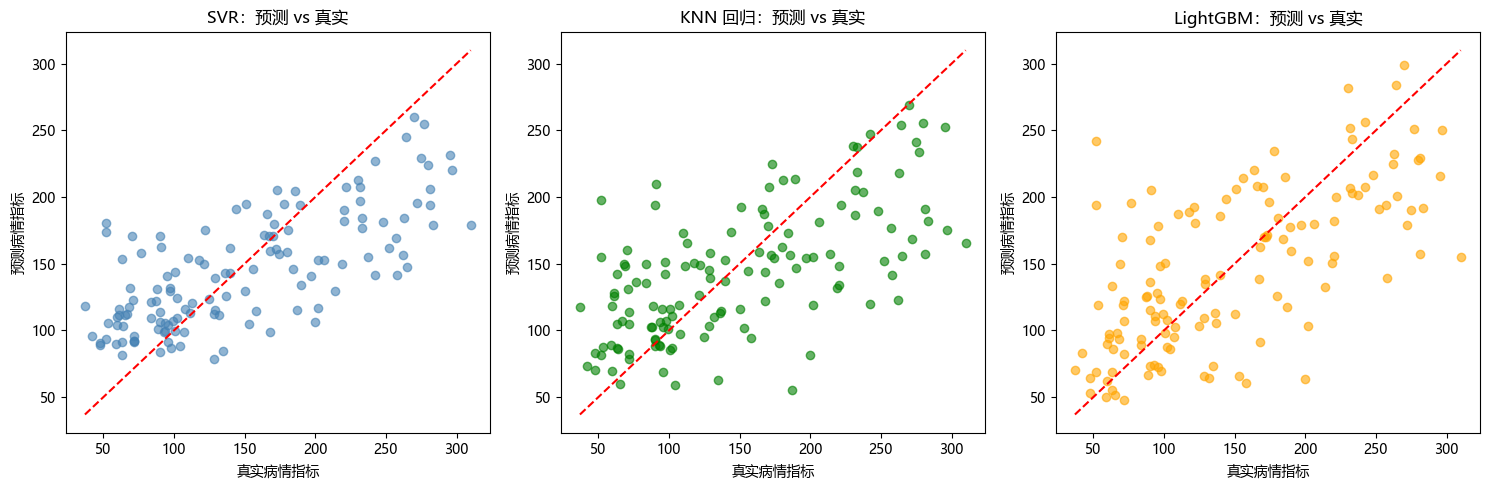

In [5]:
def evaluate_model(model, model_name: str):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{model_name}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R2:  {r2:.4f}")
    return y_pred

y_pred_svr = evaluate_model(svr, "SVR（回归）")
y_pred_knn = evaluate_model(knn_reg, "KNN 回归")
y_pred_lgbm = evaluate_model(lgbm_reg, "LightGBM 回归")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_preds = [
    ("SVR", y_pred_svr, "steelblue"),
    ("KNN 回归", y_pred_knn, "green"),
    ("LightGBM", y_pred_lgbm, "orange"),
]
for ax, (name, y_pred, color) in zip(axes, models_preds):
    ax.scatter(y_test, y_pred, alpha=0.6, color=color)
    lo, hi = float(y_test.min()), float(y_test.max())
    ax.plot([lo, hi], [lo, hi], "r--")
    ax.set_xlabel("真实病情指标")
    ax.set_ylabel("预测病情指标")
    ax.set_title(f"{name}：预测 vs 真实")
plt.tight_layout()
plt.show()


## 5. 参数调优与对比分析

使用 `RandomizedSearchCV`（`cv=5`，`scoring='r2'`）对 **SVR**、**KNN 回归**、**LightGBM 回归** 分别做随机搜索（`n_iter=25`，可自行加大）。在**同一 Hold-out 测试集**上对比 **调参前**（第 3 节默认超参数）与 **调参后** 的 MSE / R²，并绘制 R² 柱状对比图。


=== 测试集：调参前（第 3 节默认超参数）===

      模型         MSE       R2
     SVR 2704.955465 0.498925
     KNN 3190.614716 0.408960
LightGBM 3085.338062 0.428462

SVR 最优参数: {'C': np.float64(20.54051942538844), 'epsilon': np.float64(0.00861257919259488), 'gamma': 'auto'}
SVR 交叉验证最优 R2: 0.4145

KNN 最优参数: {'n_neighbors': 14, 'p': 2, 'weights': 'distance'}
KNN 交叉验证最优 R2: 0.4142

LightGBM 最优参数: {'learning_rate': np.float64(0.019665923318213548), 'max_depth': 10, 'min_child_samples': 39, 'n_estimators': 338, 'num_leaves': 19}
LightGBM 交叉验证最优 R2: 0.4113

=== 测试集：调参后（各模型 RandomizedSearchCV.best_estimator_）===

      模型         MSE       R2
     SVR 2581.954185 0.521710
     KNN 3008.628895 0.442672
LightGBM 2763.782336 0.488028


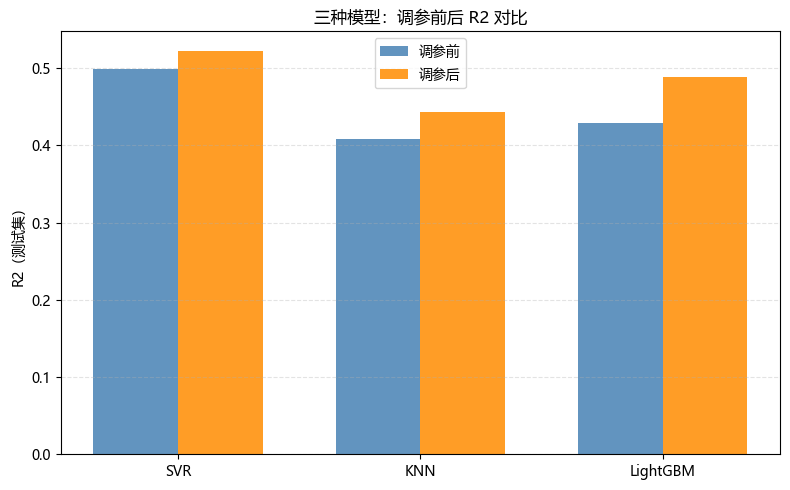

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint


def eval_on_test(model, label: str) -> dict:
    pred = model.predict(X_test)
    return {
        "模型": label,
        "MSE": mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }


print("=== 测试集：调参前（第 3 节默认超参数）===\n")
baseline_df = pd.DataFrame(
    [
        eval_on_test(svr, "SVR"),
        eval_on_test(knn_reg, "KNN"),
        eval_on_test(lgbm_reg, "LightGBM"),
    ]
)
print(baseline_df.to_string(index=False))

RANDOM_STATE = 42
N_ITER = 25
CV = 5

# --- SVR ---
svr_search = RandomizedSearchCV(
    SVR(kernel="rbf"),
    param_distributions={
        "C": loguniform(1e-2, 1e3),
        "epsilon": loguniform(1e-3, 1.0),
        "gamma": ["scale", "auto"],
    },
    n_iter=N_ITER,
    scoring="r2",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
svr_search.fit(X_train, y_train)
print("\nSVR 最优参数:", svr_search.best_params_)
print("SVR 交叉验证最优 R2:", round(float(svr_search.best_score_), 4))

# --- KNN 回归 ---
knn_search = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_distributions={
        "n_neighbors": randint(3, 31),
        "weights": ["uniform", "distance"],
        "p": [1, 2],
    },
    n_iter=N_ITER,
    scoring="r2",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
knn_search.fit(X_train, y_train)
print("\nKNN 最优参数:", knn_search.best_params_)
print("KNN 交叉验证最优 R2:", round(float(knn_search.best_score_), 4))

# --- LightGBM ---
lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        "n_estimators": randint(50, 401),
        "learning_rate": loguniform(0.01, 0.3),
        "num_leaves": randint(15, 64),
        "max_depth": randint(3, 12),
        "min_child_samples": randint(5, 41),
    },
    n_iter=N_ITER,
    scoring="r2",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lgbm_search.fit(X_train, y_train)
print("\nLightGBM 最优参数:", lgbm_search.best_params_)
print("LightGBM 交叉验证最优 R2:", round(float(lgbm_search.best_score_), 4))

print("\n=== 测试集：调参后（各模型 RandomizedSearchCV.best_estimator_）===\n")
tuned_df = pd.DataFrame(
    [
        eval_on_test(svr_search.best_estimator_, "SVR"),
        eval_on_test(knn_search.best_estimator_, "KNN"),
        eval_on_test(lgbm_search.best_estimator_, "LightGBM"),
    ]
)
print(tuned_df.to_string(index=False))

# R2 对比柱状图
labels = ["SVR", "KNN", "LightGBM"]
r2_before = baseline_df["R2"].to_list()
r2_after = tuned_df["R2"].to_list()
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, r2_before, width, label="调参前", color="steelblue", alpha=0.85)
ax.bar(x + width / 2, r2_after, width, label="调参后", color="darkorange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("R2（测试集）")
ax.set_title("三种模型：调参前后 R2 对比")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


## 6. 模型保存与加载（示例：LightGBM）

选定 **一个** 模型做持久化：这里保存 **LightGBM 回归器**（`LGBMRegressor`，sklearn 接口）。

- **保存**：使用 [`joblib`](https://scikit-learn.org/stable/modules/model_persistence.html)（与 sklearn 文档一致，适合含 NumPy 数组的模型）。
- **策略**：若你已运行上一节并得到 `lgbm_search`，则自动保存 **调参后** 的 `best_estimator_`；否则保存第 3 节中的 **`lgbm_reg`**。
- 文件写入当前工作目录下的 `artifacts/models/`（仓库 `.gitignore` 已忽略该目录，避免误提交二进制）。


In [7]:
from pathlib import Path

import joblib
import numpy as np

# 若已运行「参数调优」单元且存在 lgbm_search，优先保存调参后的模型
if "lgbm_search" in globals():
    model_to_save = lgbm_search.best_estimator_
    tag = "tuned"
else:
    model_to_save = lgbm_reg
    tag = "default"

MODEL_DIR = Path("artifacts") / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
out_path = MODEL_DIR / f"lgbm_diabetes_regressor_{tag}.joblib"

joblib.dump(model_to_save, out_path)
print("已保存:", out_path.resolve())
print("保存对象:", type(model_to_save).__name__, "|", tag)

loaded = joblib.load(out_path)

pred_orig = model_to_save.predict(X_test)
pred_load = loaded.predict(X_test)
max_abs_diff = float(np.max(np.abs(pred_load - pred_orig)))
print("加载后预测与保存前最大绝对误差:", max_abs_diff)
assert max_abs_diff < 1e-9
print("校验通过：加载模型预测一致。")


已保存: D:\Project\ml-lab-classic\ml-lab-classic\notebooks\artifacts\models\lgbm_diabetes_regressor_tuned.joblib
保存对象: LGBMRegressor | tuned
加载后预测与保存前最大绝对误差: 0.0
校验通过：加载模型预测一致。
